<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
import requests

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
r = requests.get(url)

with open('survey-data.csv', 'wb') as f:
    f.write(r.content)

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



In [4]:
hist_comp = df[['ConvertedCompYearly']]
hist_comp = hist_comp.dropna()
q1 = hist_comp['ConvertedCompYearly'].quantile(.25)
q3 = hist_comp['ConvertedCompYearly'].quantile(.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
hist_comp = hist_comp[hist_comp['ConvertedCompYearly'] <= upper_bounds] # removing outliers for readability

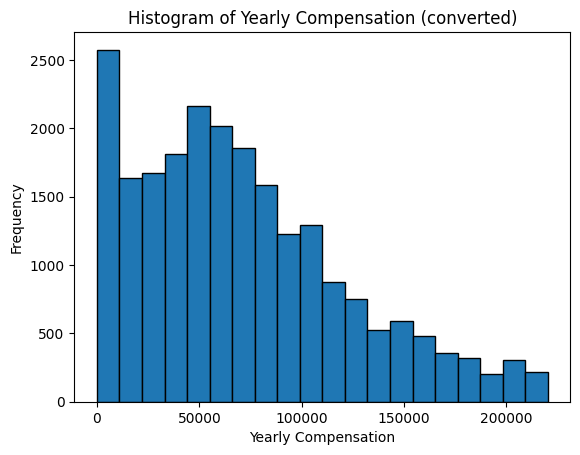

In [5]:
plt.hist(hist_comp,
         bins = 20,
         edgecolor = 'black')
plt.xlabel('Yearly Compensation')
plt.ylabel('Frequency')
plt.title('Histogram of Yearly Compensation (converted)')
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



In [6]:
box_age = df[['Age']]
box_age = box_age.dropna()
box_age = box_age[box_age['Age'] != 'Prefer not to say']
box_age = box_age.replace('Under 18 years old', str(17)) # need it as string for next operation to work properly
box_age['Age'] = box_age['Age'].str[0:2] # shortening age groups to first two characters (youngest age in group)
box_age['Age'] = box_age['Age'].astype(int)
box_age.value_counts()

Age
25     23911
35     14942
18     14098
45      6249
55      2575
17      2568
65       772
Name: count, dtype: int64

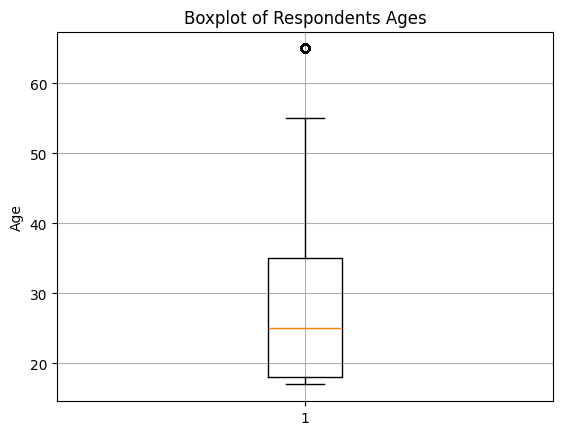

In [7]:
plt.boxplot(box_age['Age'])
plt.grid('y')
plt.ylabel('Age')
plt.title('Boxplot of Respondents Ages')
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



In [8]:
scat_age_comp = df[['Age', 'ConvertedCompYearly']]
scat_age_comp = scat_age_comp.dropna()
scat_age_comp = scat_age_comp[scat_age_comp['Age'] != 'Prefer not to say']
scat_age_comp = scat_age_comp.replace('Under 18 years old', str(17)) # need it as string for next operation to work properly
scat_age_comp['Age'] = scat_age_comp['Age'].str[0:2] # shortening age groups to first two characters (youngest age in group)
scat_age_comp['Age'] = scat_age_comp['Age'].astype(int)
scat_age_comp.head()

,Age,ConvertedCompYearly
72,18,7322.0
374,25,30074.0
379,35,91295.0
385,35,53703.0
389,25,110000.0


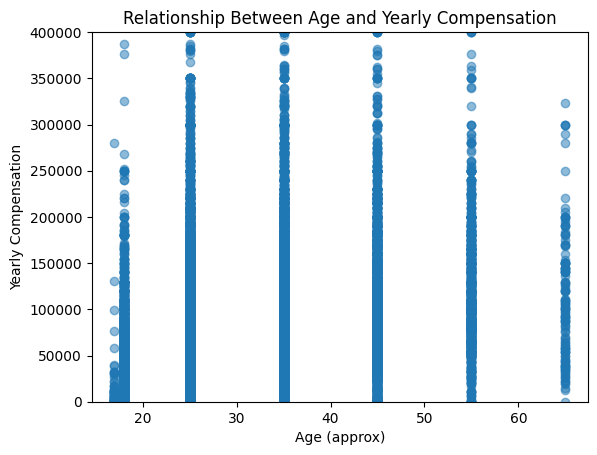

In [9]:
plt.scatter(scat_age_comp['Age'],
            scat_age_comp['ConvertedCompYearly'],
            alpha = 0.5)
plt.xlabel('Age (approx)')
plt.ylabel('Yearly Compensation')
plt.ylim(0, 400000) # didn't feel like doing outliers, just zoomed in instead
plt.title('Relationship Between Age and Yearly Compensation')
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


In [10]:
bub_comp_sat = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']]
bub_comp_sat = bub_comp_sat.dropna()
bub_comp_sat = bub_comp_sat[bub_comp_sat['Age'] != 'Prefer not to say']
bub_comp_sat = bub_comp_sat.replace('Under 18 years old', str(17)) # need it as string for next operation to work properly
bub_comp_sat['Age'] = bub_comp_sat['Age'].str[0:2] # shortening age groups to first two characters (youngest age in group)
bub_comp_sat['Age'] = bub_comp_sat['Age'].astype(int)
bub_comp_sat.head()

,ConvertedCompYearly,JobSatPoints_6,Age
72,7322.0,65.0,18
379,91295.0,0.0,35
389,110000.0,20.0,25
392,161044.0,30.0,35
398,195000.0,30.0,45


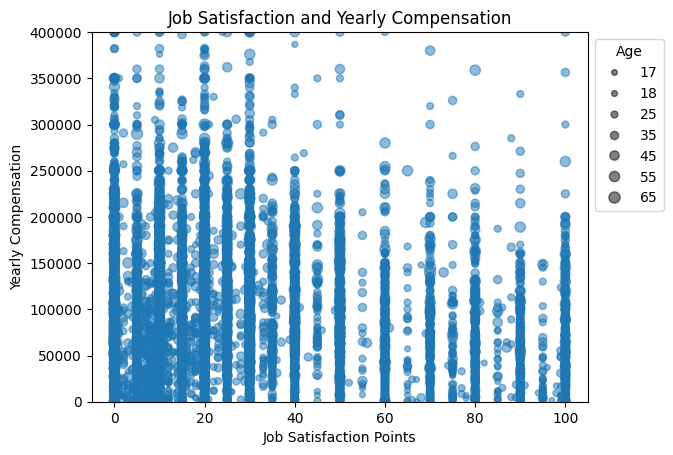

In [11]:
fig, ax = plt.subplots()
scatter = ax.scatter(bub_comp_sat['JobSatPoints_6'],
                     bub_comp_sat['ConvertedCompYearly'],
                     s = bub_comp_sat['Age'],
                     alpha = 0.5)

legend = ax.legend(*scatter.legend_elements(prop = 'sizes'),
                   bbox_to_anchor= (1, 1), title='Age')

plt.xlabel('Job Satisfaction Points')
plt.ylabel('Yearly Compensation')
plt.ylim(0, 400000)
plt.title('Job Satisfaction and Yearly Compensation')
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



In [12]:
barh_branch = df[['MainBranch']]
barh_branch = barh_branch.value_counts(subset = 'MainBranch').reset_index()
barh_branch

,MainBranch,count
0,I am a developer by profession,50207
1,"I am not primarily a developer, but I write co...",6511
2,I am learning to code,3875
3,I code primarily as a hobby,3334
4,"I used to be a developer by profession, but no...",1510


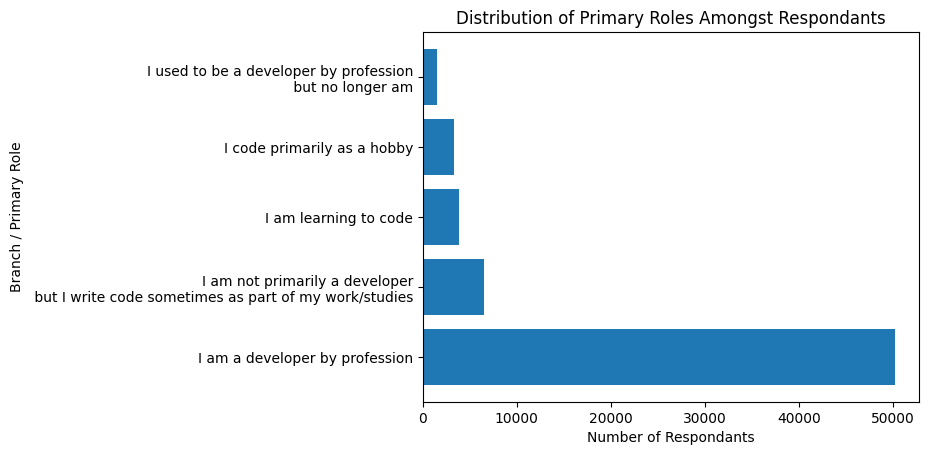

In [13]:
labels = barh_branch['MainBranch'].values
wrapped_labels = [label.replace(',', '\n') for label in labels]

plt.barh(barh_branch['MainBranch'],
         barh_branch['count'],
         tick_label = wrapped_labels)
plt.xlabel('Number of Respondants')
plt.ylabel('Branch / Primary Role')
plt.title('Distribution of Primary Roles Amongst Respondants')
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



In [14]:
bar_lang = df[['LanguageWantToWorkWith']]
bar_lang = bar_lang.dropna()
bar_lang['Lang'] = bar_lang['LanguageWantToWorkWith'].str.split(';')
bar_lang = bar_lang.drop('LanguageWantToWorkWith', axis = 1)
bar_lang = bar_lang.explode('Lang').reset_index(drop = True)
bar_lang.value_counts()

Lang                   
Python                     25047
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Java                       10668
C                           8275
Kotlin                      7379
PHP                         5745
PowerShell                  4287
Swift                       3877
Dart                        3709
Zig                         3688
Lua                         3322
Assembly                    3007
Elixir                      2895
Ruby                        2774
Haskell                     2221
R                           2177
Scala                       1790
GDScript                    1667
Clojure                     1331
F#                          1272
Julia                       1263
Lisp               

In [15]:
top5 = list(bar_lang['Lang'].value_counts().head().index)
top5
rows = bar_lang.loc[bar_lang['Lang'].isin(top5) == False]
bar_lang = bar_lang.drop(rows.index)
bar_lang = bar_lang.value_counts(subset='Lang').reset_index()
bar_lang

,Lang,count
0,Python,25047
1,JavaScript,23774
2,SQL,22400
3,HTML/CSS,20721
4,TypeScript,20239


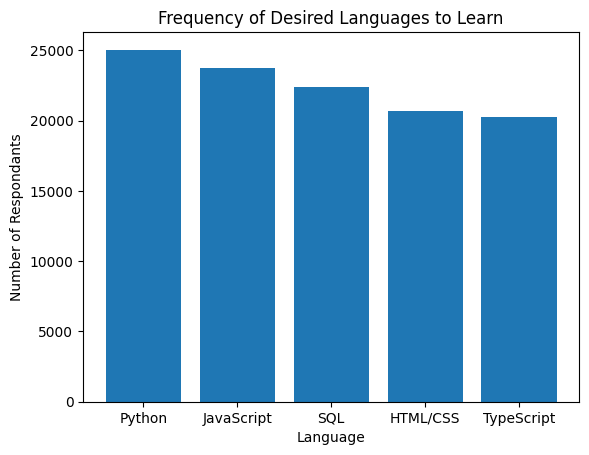

In [16]:
plt.bar(bar_lang['Lang'],
        bar_lang['count'])
plt.xlabel('Language')
plt.ylabel('Number of Respondants')
plt.title('Frequency of Desired Languages to Learn')
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


In [17]:
stacked_sat_age = df[['JobSatPoints_6', 'JobSatPoints_7', 'Age']]
stacked_sat_age = stacked_sat_age.dropna()
stacked_sat_age = stacked_sat_age[stacked_sat_age['Age'] != 'Prefer not to say']
stacked_sat_age = stacked_sat_age.replace('Under 18 years old', '13-17 years old')
stacked_sat_age.head()

,JobSatPoints_6,JobSatPoints_7,Age
1,0.0,0.0,35-44 years old
10,25.0,10.0,35-44 years old
12,30.0,0.0,35-44 years old
15,0.0,0.0,45-54 years old
18,60.0,10.0,25-34 years old


In [18]:
stacked_sat6_age = stacked_sat_age.groupby('Age')['JobSatPoints_6'].median().reset_index()
stacked_sat7_age = stacked_sat_age.groupby('Age')['JobSatPoints_7'].median().reset_index()

In [19]:
stacked_sat6_age

,Age,JobSatPoints_6
0,13-17 years old,1.5
1,18-24 years old,15.0
2,25-34 years old,20.0
3,35-44 years old,20.0
4,45-54 years old,20.0
5,55-64 years old,20.0
6,65 years or older,20.0


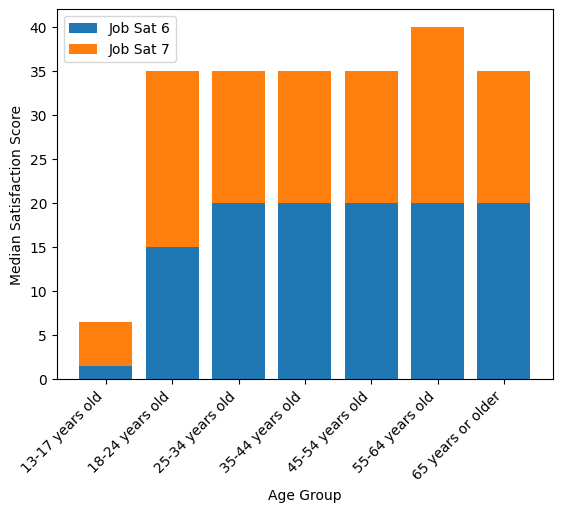

In [20]:
plt.bar(stacked_sat6_age['Age'],
        stacked_sat6_age['JobSatPoints_6'])
plt.bar(stacked_sat7_age['Age'],
        stacked_sat7_age['JobSatPoints_7'],
        bottom = stacked_sat6_age['JobSatPoints_6'])
plt.xlabel('Age Group')
plt.xticks(rotation = 45,
           ha = 'right')
plt.ylabel('Median Satisfaction Score')
plt.legend(labels = ['Job Sat 6', 'Job Sat 7'])
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



In [21]:
bar_db = df[['DatabaseHaveWorkedWith']]
bar_db = bar_db.dropna()
bar_db['Database'] = bar_db['DatabaseHaveWorkedWith'].str.split(';')
bar_db = bar_db.explode('Database')
bar_db = bar_db.drop('DatabaseHaveWorkedWith', axis = 1)
bar_db = bar_db.reset_index(drop = True)
bar_db = bar_db.value_counts(subset = 'Database').head(20).reset_index()
bar_db

,Database,count
0,PostgreSQL,25536
1,MySQL,21099
2,SQLite,17365
3,Microsoft SQL Server,13275
4,MongoDB,13007
5,Redis,10463
6,MariaDB,8991
7,Elasticsearch,6533
8,Oracle,5273
9,Dynamodb,4138


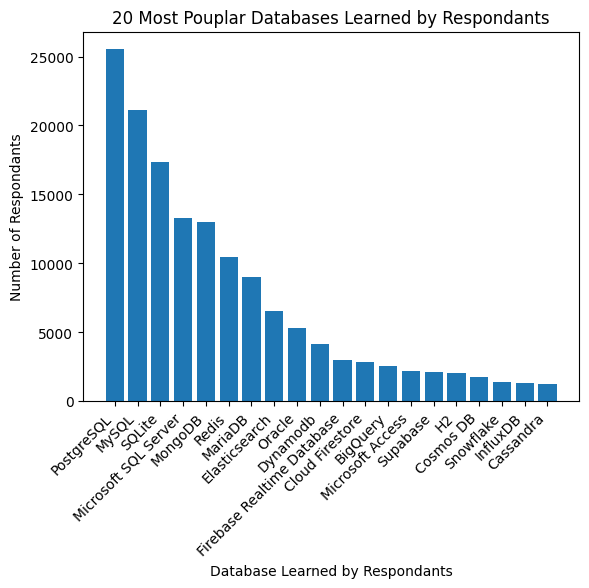

In [22]:
plt.bar(bar_db['Database'],
        bar_db['count'])
plt.xlabel('Database Learned by Respondants')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Number of Respondants')
plt.title('20 Most Pouplar Databases Learned by Respondants')
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



In [23]:
grouped_comp_age = df[['ConvertedCompYearly', 'Age',]]
grouped_comp_age = grouped_comp_age.dropna()
grouped_comp_age = grouped_comp_age.replace('Under 18 years old', '13-17 years old')
grouped_comp_age.head()

,ConvertedCompYearly,Age
72,7322.0,18-24 years old
374,30074.0,25-34 years old
379,91295.0,35-44 years old
385,53703.0,35-44 years old
389,110000.0,25-34 years old


In [24]:
grouped_bar = grouped_comp_age.groupby('Age')['ConvertedCompYearly'].median().reset_index()
grouped_bar

,Age,ConvertedCompYearly
0,13-17 years old,7626.5
1,18-24 years old,25000.0
2,25-34 years old,59825.0
3,35-44 years old,84796.0
4,45-54 years old,99099.0
5,55-64 years old,109691.0
6,65 years or older,106000.0
7,Prefer not to say,140000.0


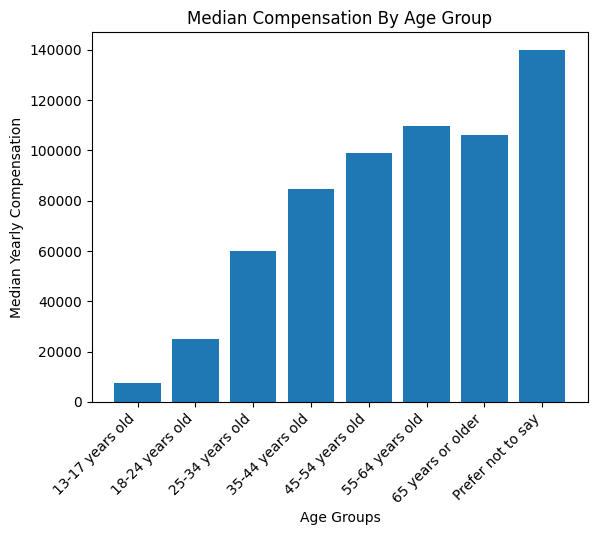

In [25]:
labels = grouped_bar['Age'].values
plt.bar(grouped_bar['Age'],
        grouped_bar['ConvertedCompYearly'],
        tick_label = labels)
plt.xlabel('Age Groups')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Median Yearly Compensation')
plt.title('Median Compensation By Age Group')
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



In [26]:
bar_country = df[['Country']]
bar_country = bar_country.dropna()
bar_country = bar_country.value_counts(subset = 'Country').reset_index()
bar_country

,Country,count
0,United States of America,11095
1,Germany,4947
2,India,4231
3,United Kingdom of Great Britain and Northern I...,3224
4,Ukraine,2672
...,...,...
180,Haiti,1
181,Nauru,1
182,Chad,1
183,Djibouti,1


In [30]:
bar_country = bar_country.head(20)
bar_country['Country'] = bar_country['Country'].replace({'United States of America': 'U.S.A.',
                                                         'United Kingdom of Great Britain and Northern Ireland': 'U.K.',
                                                         'Russian Federation': 'Russian'})

In [31]:
bar_country

,Country,count
0,U.S.A.,11095
1,Germany,4947
2,India,4231
3,U.K.,3224
4,Ukraine,2672
5,France,2110
6,Canada,2104
7,Poland,1534
8,Netherlands,1449
9,Brazil,1375


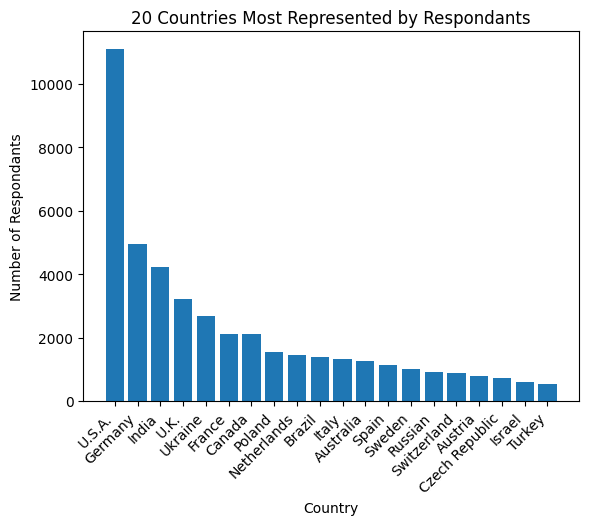

In [32]:
plt.bar(bar_country['Country'],
        bar_country['count'])
plt.xlabel('Country')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Number of Respondants')
plt.title('20 Countries Most Represented by Respondants')
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
